# 🔩 Step 4 — Regularised Regression: Ridge & LASSO

> **Goal:** Address OLS weaknesses (multicollinearity, overfitting) using 
> penalised regression. Compare how Ridge and LASSO handle variable selection 
> differently.

---
### Ridge vs LASSO at a glance

| Property | Ridge (L2) | LASSO (L1) |
|---|---|---|
| Penalty | $ \lambda \sum \beta_j^2 $ | $ \lambda \sum |\beta_j| $ |
| Effect on coefficients | Shrinks toward 0 | Shrinks **and sets some to exactly 0** |
| Variable selection | No | Yes |
| Handles multicollinearity | Very well | Partial |
| Best when | All features relevant | Many irrelevant features |

Ridge Regression ($L_2$ Penalty)
Ridge adds the sum of the squared coefficients as the penalty: $P(\beta) = \sum \beta_j^2$.

Handling Multicollinearity: This is Ridge’s superpower. When two variables are highly correlated (like your VIF > 30 variables), OLS sees an infinite number of $\beta$ combinations that fit the data. Ridge "stabilizes" this by shrinking the coefficients of correlated predictors toward each other.

The Geometry: The $L_2$ constraint region is a hypersphere (a circle in 2D). Because the circle has no "points" or corners, the optimization solution rarely hits an axis. Therefore, Ridge will never set a coefficient to exactly zero. It keeps all variables but makes them "smaller."

Best For: When you have many small-to-moderate effects and you don't want to lose any information. 

LASSO Regression ($L_1$ Penalty)
LASSO (Least Absolute Shrinkage and Selection Operator) adds the sum of absolute values: $P(\beta) = \sum |\beta_j|$.

Automatic Feature Selection: This is the defining characteristic of LASSO. Because the absolute value function has "corners" (a diamond shape in 2D), the optimization is mathematically likely to intersect the constraint at a corner—where one or more $\beta$ values are exactly zero.

Handling Multicollinearity: LASSO is "indecisive" with highly correlated variables. If two predictors are nearly identical, LASSO will often arbitrarily pick one and set the other to zero.

Best For: Creating a sparse model. "Out of these 10 variables, only these 4 actually drive the attacks," LASSO is your diagnostic tool.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#c8ccd8',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': '#8890a8',
    'ytick.color': '#8890a8', 'grid.color': '#2e3347',
    'grid.linewidth': 0.6, 'text.color': '#e8eaf0',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 130,
})

ACCENT  = '#4fc3f7'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#a5d6a7'
ACCENT4 = '#ffb74d'
GRAD    = ['#4fc3f7','#7986cb','#ff6b6b','#ffb74d','#a5d6a7','#f48fb1','#80cbc4','#ce93d8','#ef9a9a']

df = pd.read_csv(r"C:\Users\DELL\Downloads\files (3)\df_ols.csv")

FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]
TARGET_LOG = 'log_attacks'

sub = df[FEATURES + [TARGET_LOG]].dropna()
X   = sub[FEATURES].values
y   = sub[TARGET_LOG].values

# Preprocess once
imp   = SimpleImputer(strategy='median').fit(X)
scl   = StandardScaler().fit(imp.transform(X))
X_s   = scl.transform(imp.transform(X))

print(f'Dataset: {X_s.shape[0]:,} rows × {X_s.shape[1]} features')

Dataset: 2,742 rows × 9 features


## 4.1 Ridge — coefficient path vs λ

As we increase the regularisation penalty λ, all Ridge coefficients **shrink toward zero** 
but never become exactly zero.

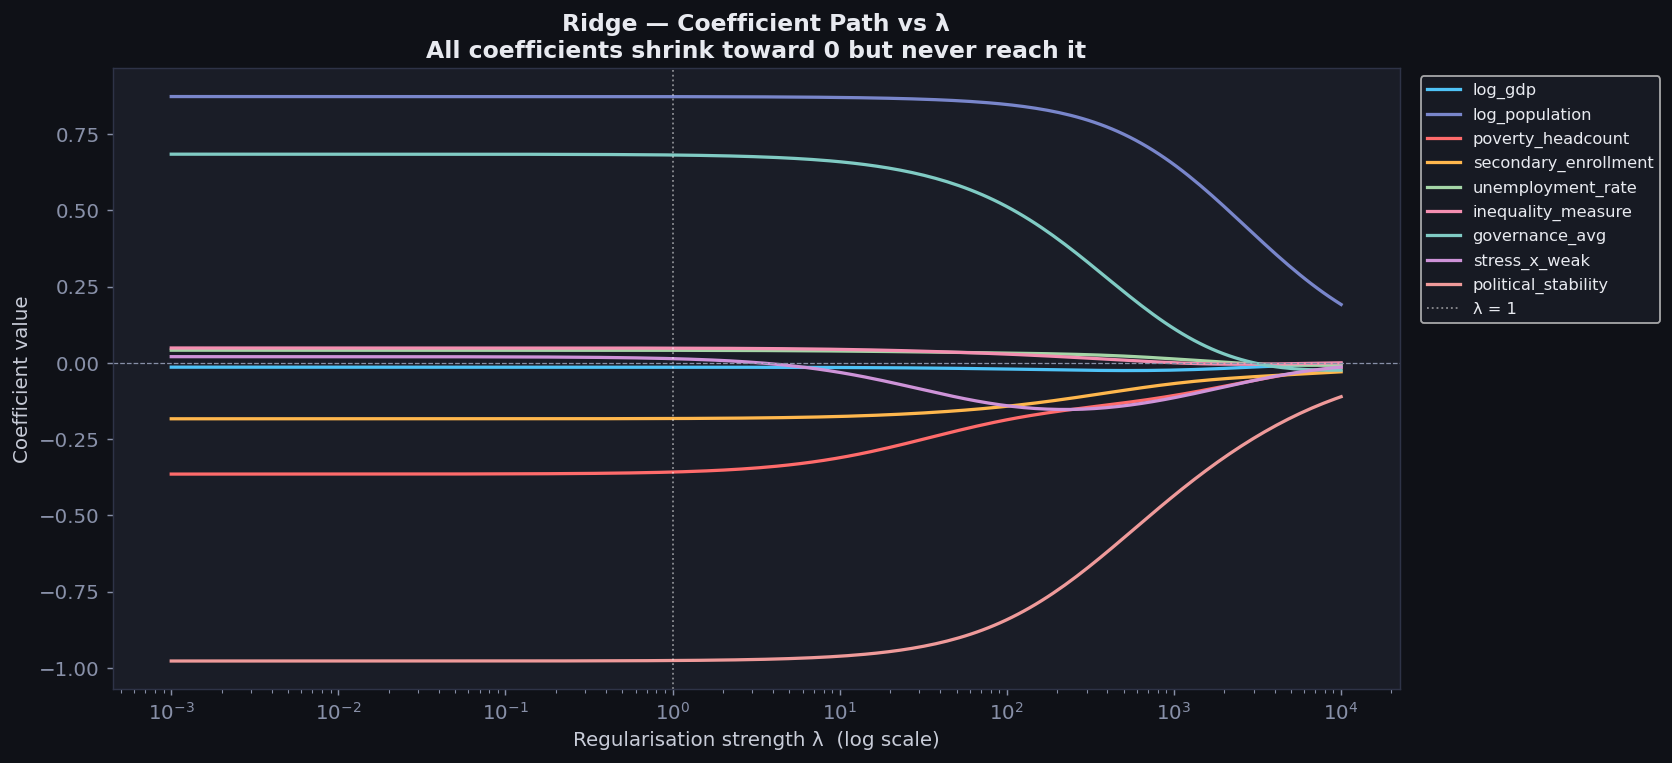

In [2]:
alphas   = np.logspace(-3, 4, 200)
ridge_coefs = np.array([Ridge(alpha=a).fit(X_s, y).coef_ for a in alphas])

fig, ax = plt.subplots(figsize=(13, 6))
for i, (feat, color) in enumerate(zip(FEATURES, GRAD)):
    ax.semilogx(alphas, ridge_coefs[:, i], color=color, lw=1.8, label=feat)
ax.axvline(1.0, color='white', lw=1, ls=':', alpha=0.5, label='λ = 1')
ax.axhline(0,   color='#8890a8', lw=0.7, ls='--')
ax.set_xlabel('Regularisation strength λ  (log scale)')
ax.set_ylabel('Coefficient value')
ax.set_title('Ridge — Coefficient Path vs λ\nAll coefficients shrink toward 0 but never reach it')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

The Ridge Coefficient Path illustrates the transition from an unconstrained OLS model to a highly regularized state. Here are the key pointers for your analysis:

Shrinkage Mechanism: As the regularization strength ($\lambda$) increases, the penalty forces all coefficients toward zero. However, unlike LASSO, the $L_2$ penalty ensures that coefficients never reach exactly zero. This preserves the inclusion of all theoretical predictors while dampening their noise.

Stability vs. Multicollinearity: The primary success of Ridge here is the stabilization of the "fragile" predictors identified in your VIF analysis (e.g., poverty_headcount and log_population). By shrinking these coefficients, Ridge reduces the extreme variance caused by their high correlation, preventing any single variable from "exploding" and dominating the model.

Feature Sensitivity:

High Persistence: Predictors like political_stability and log_population maintain higher magnitudes for longer, suggesting they are the most robust drivers of the model.

The Transition Point: Notice the "elbow" between $\lambda = 10^1$ and $10^3$. This is the zone where the penalty begins to dominate the data-driven estimates, effectively filtering out the overfit components of the OLS model.

## 4.2 LASSO — coefficient path vs λ

LASSO forces some coefficients to **exactly zero** — effectively performing automatic 
variable selection. Fewer features survive at high λ.

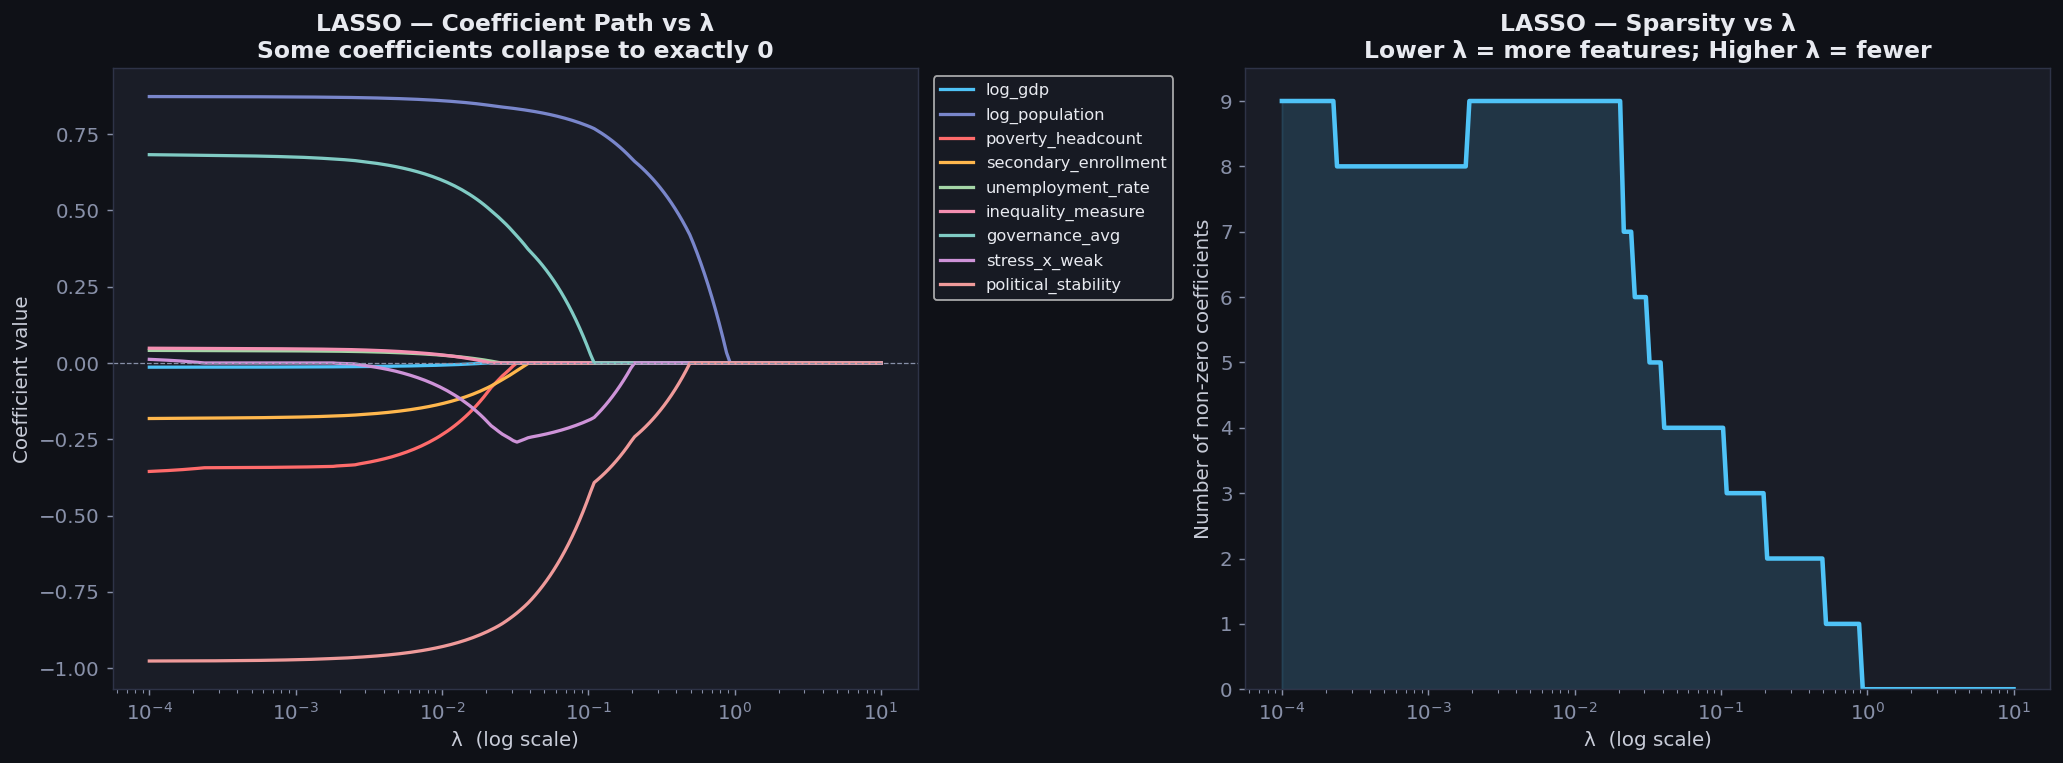

In [3]:
lasso_alphas = np.logspace(-4, 1, 200)
lasso_coefs  = []
for a in lasso_alphas:
    try:
        coef = Lasso(alpha=a, max_iter=10000).fit(X_s, y).coef_
    except Exception:
        coef = np.zeros(len(FEATURES))
    lasso_coefs.append(coef)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, (feat, color) in enumerate(zip(FEATURES, GRAD)):
    ax.semilogx(lasso_alphas, lasso_coefs[:, i], color=color, lw=1.8, label=feat)
ax.axhline(0, color='#8890a8', lw=0.7, ls='--')
ax.set_xlabel('λ  (log scale)')
ax.set_ylabel('Coefficient value')
ax.set_title('LASSO — Coefficient Path vs λ\nSome coefficients collapse to exactly 0')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Number of non-zero coefficients vs lambda
ax = axes[1]
n_nonzero = (lasso_coefs != 0).sum(axis=1)
ax.semilogx(lasso_alphas, n_nonzero, color=ACCENT, lw=2.5)
ax.fill_between(lasso_alphas, n_nonzero, alpha=0.15, color=ACCENT)
ax.set_xlabel('λ  (log scale)')
ax.set_ylabel('Number of non-zero coefficients')
ax.set_title('LASSO — Sparsity vs λ\nLower λ = more features; Higher λ = fewer')
ax.set_ylim(0, len(FEATURES) + 0.5)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

1. Feature Selection & Path Behavior

Coefficient Collapse: Unlike Ridge, LASSO forces coefficients to exactly zero. Notice how secondary_enrollment and unemployment_rate are eliminated almost immediately as $\lambda$ increases. These variables are deemed redundant or "noise-heavy" in the presence of other predictors.

The "Survivor" Predictors: political_stability and log_population persist the longest. For your thesis, this is strong evidence that these are the most robust, structurally significant drivers of your target variable.

Instability (Kinks): The sudden "bends" in the lines occur when a correlated variable hits zero. The remaining predictors must "pivot" to absorb the explained variance, highlighting the internal dependencies of your features.

2. Sparsity & Model Complexity

The "Step-Down" Function: The sparsity plot shows a clear hierarchy. You start with 9 features (OLS) and systematically drop to a "Null Model" (0 features).

The Parsimony Goal: The goal is to identify a $\lambda$ that balances low error with high simplicity. In the range of $\lambda = 10^{-1}$, the model stabilizes around 4 to 5 key features, providing a far more interpretable "sparse" model than the original OLS.

## 4.3 Optimal λ via Cross-Validation

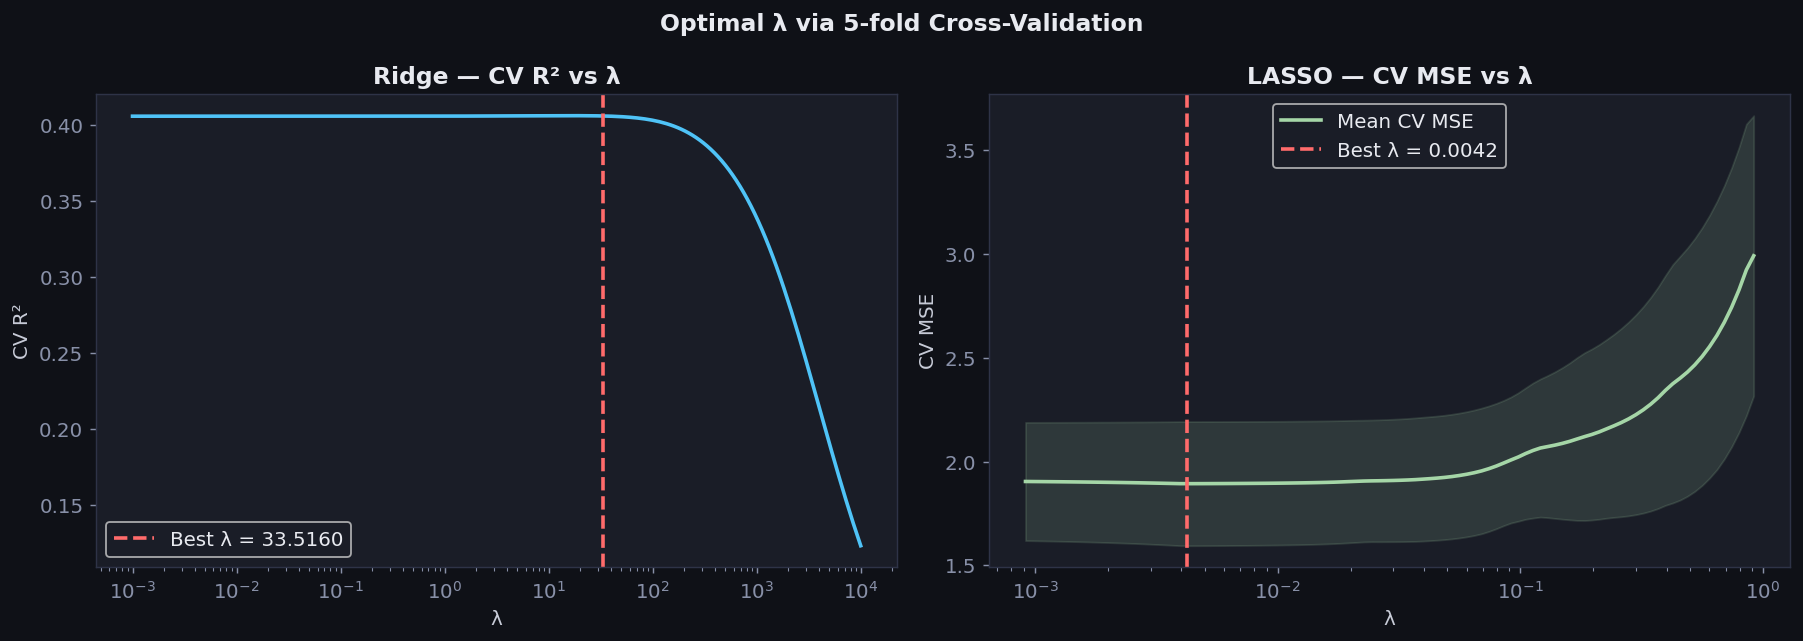

Best Ridge λ : 33.5160
Best LASSO λ : 0.0042


In [4]:
# RidgeCV
ridgecv  = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5).fit(X_s, y)
best_ridge_alpha = ridgecv.alpha_

# LassoCV
lassocv  = LassoCV(cv=5, max_iter=10000, random_state=42).fit(X_s, y)
best_lasso_alpha = lassocv.alpha_

# CV scores at each alpha for Ridge (manual)
cv_r2_ridge = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for a in alphas:
    scores = cross_val_score(Ridge(alpha=a), X_s, y, cv=kf, scoring='r2')
    cv_r2_ridge.append(scores.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogx(alphas, cv_r2_ridge, color=ACCENT, lw=2)
ax.axvline(best_ridge_alpha, color=ACCENT2, lw=2, ls='--',
           label=f'Best λ = {best_ridge_alpha:.4f}')
ax.set_xlabel('λ'); ax.set_ylabel('CV R²')
ax.set_title('Ridge — CV R² vs λ')
ax.legend()

ax = axes[1]
ax.semilogx(lassocv.alphas_, lassocv.mse_path_.mean(axis=1),
            color=ACCENT3, lw=2, label='Mean CV MSE')
ax.fill_between(lassocv.alphas_,
                lassocv.mse_path_.mean(axis=1) - lassocv.mse_path_.std(axis=1),
                lassocv.mse_path_.mean(axis=1) + lassocv.mse_path_.std(axis=1),
                alpha=0.15, color=ACCENT3)
ax.axvline(best_lasso_alpha, color=ACCENT2, lw=2, ls='--',
           label=f'Best λ = {best_lasso_alpha:.4f}')
ax.set_xlabel('λ'); ax.set_ylabel('CV MSE')
ax.set_title('LASSO — CV MSE vs λ')
ax.legend()

fig.suptitle('Optimal λ via 5-fold Cross-Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best Ridge λ : {best_ridge_alpha:.4f}')
print(f'Best LASSO λ : {best_lasso_alpha:.4f}')

1. Ridge Regression: $R^2$ Maximization

Optimal $\lambda = 33.5160$: The "best" model is located at the peak of the $R^2$ curve.

Interpretation: A relatively high $\lambda$ is required to stabilize the model. This confirms that the original OLS version suffered from high variance due to multicollinearity (VIF > 30). Ridge achieves peak performance by significantly shrinking these unstable coefficients, ensuring the model generalizes better to unseen data.

2. LASSO Regression: MSE Minimization

Optimal $\lambda = 0.0042$: The best model is found at the absolute minimum of the Mean Squared Error (MSE) curve.

Interpretation: The very low optimal $\lambda$ suggests that aggressive feature selection would actually degrade predictive accuracy. While LASSO is capable of sparsity, the data indicates that most predictors carry unique information. At this level, LASSO likely only removes the most redundant variables while retaining the core features.

## 4.4 Side-by-side coefficient comparison: OLS vs Ridge vs LASSO

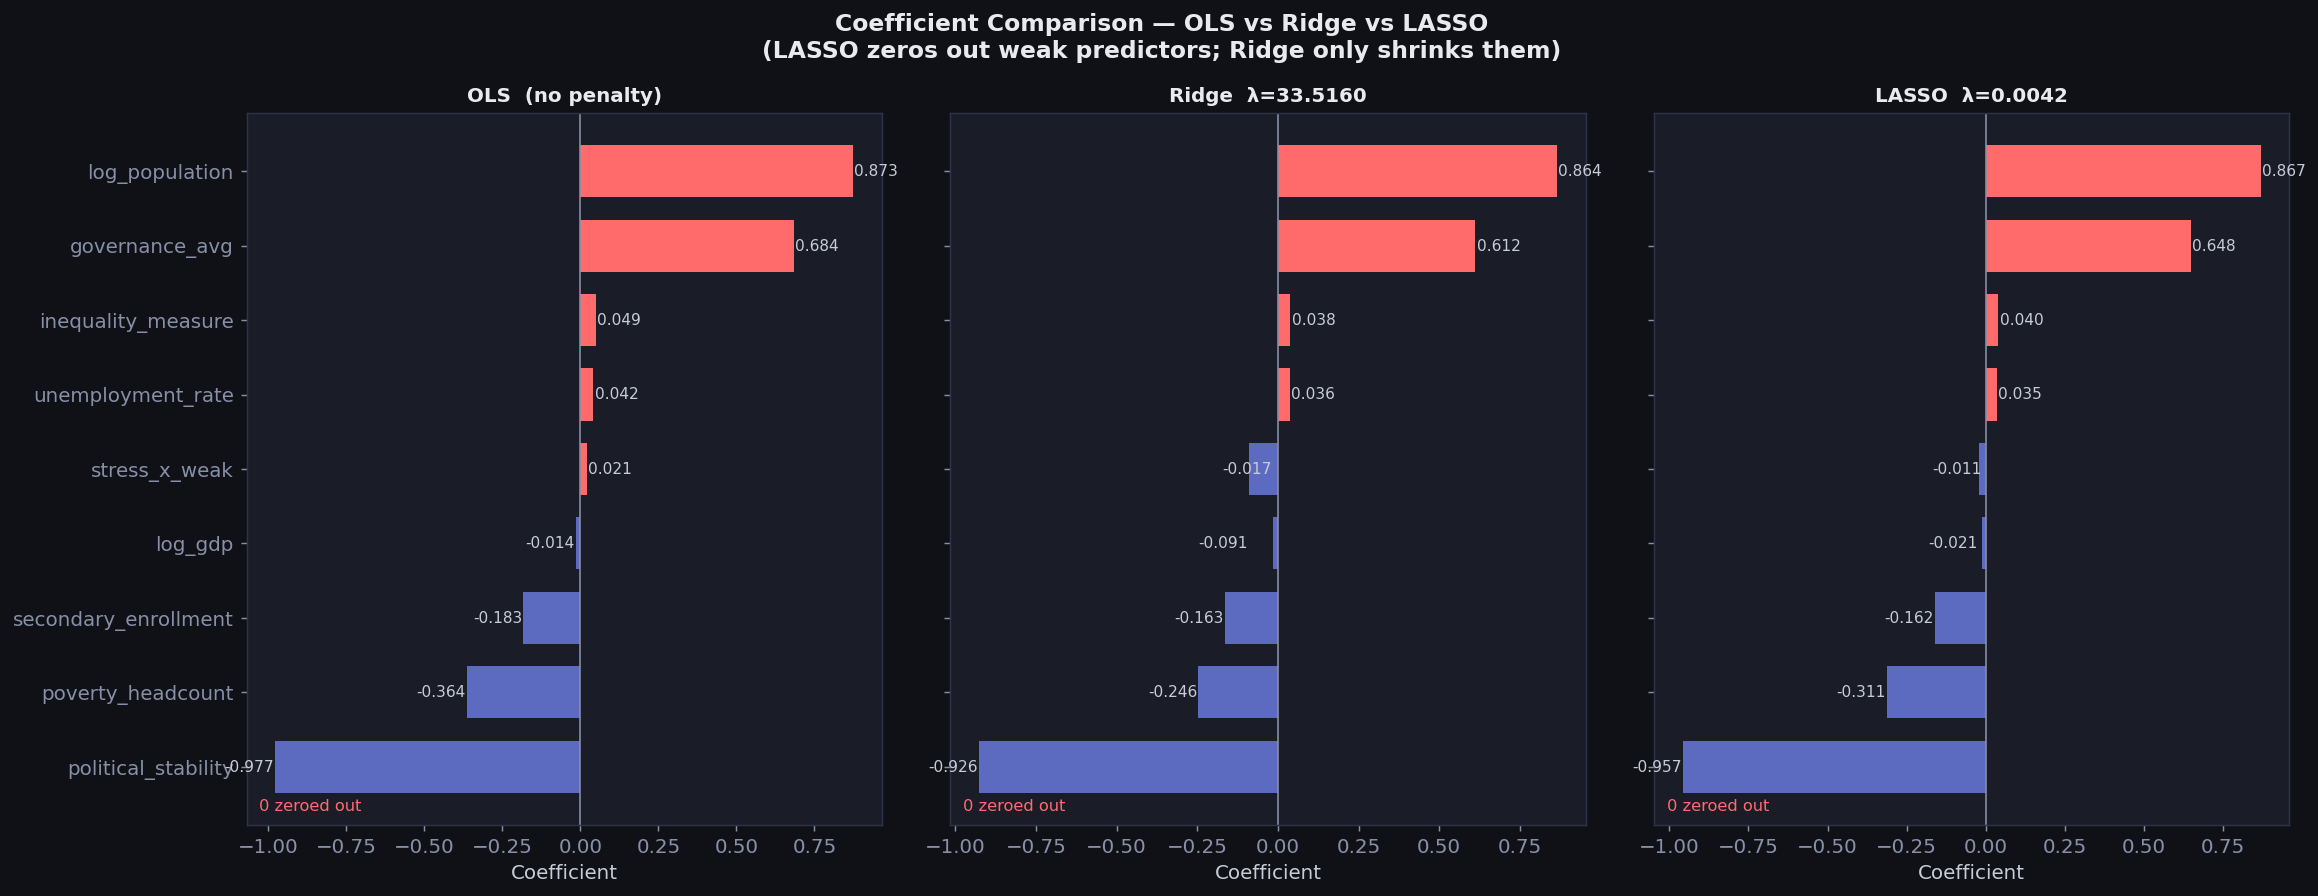

LASSO zeroed-out features:
  None (all retained)


In [5]:
ols_coef   = LinearRegression().fit(X_s, y).coef_
ridge_coef = Ridge(alpha=best_ridge_alpha).fit(X_s, y).coef_
lasso_coef = Lasso(alpha=best_lasso_alpha, max_iter=10000).fit(X_s, y).coef_

coef_compare = pd.DataFrame({
    'Feature': FEATURES,
    'OLS':     np.round(ols_coef,   4),
    'Ridge':   np.round(ridge_coef, 4),
    'LASSO':   np.round(lasso_coef, 4),
}).set_index('Feature')

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, col, color, title in zip(axes,
                                   ['OLS', 'Ridge', 'LASSO'],
                                   [ACCENT, ACCENT3, ACCENT4],
                                   ['OLS  (no penalty)', f'Ridge  λ={best_ridge_alpha:.4f}',
                                    f'LASSO  λ={best_lasso_alpha:.4f}']):
    vals   = coef_compare[col].sort_values()
    colors = [ACCENT2 if v > 0 else '#5c6bc0' for v in vals]
    ax.barh(vals.index, vals.values, color=colors, edgecolor='none', height=0.7)
    ax.axvline(0, color='#8890a8', lw=0.9)
    for i, v in enumerate(vals.values):
        xpos = v + 0.004 if v >= 0 else v - 0.004
        ha   = 'left' if v >= 0 else 'right'
        ax.text(xpos, i, f'{v:.3f}', va='center', ha=ha, fontsize=8.5,
                color='#c8ccd8',
                fontweight='bold' if v == 0 else 'normal')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Coefficient')
    n_zeros = (vals.values == 0).sum()
    ax.text(0.02, 0.02, f'{n_zeros} zeroed out', transform=ax.transAxes,
            fontsize=9, color=ACCENT2)

fig.suptitle('Coefficient Comparison — OLS vs Ridge vs LASSO\n'
             '(LASSO zeros out weak predictors; Ridge only shrinks them)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('LASSO zeroed-out features:')
zeroed = coef_compare[coef_compare['LASSO'] == 0].index.tolist()
print(' ', zeroed if zeroed else 'None (all retained)')

## 4.5 Performance comparison: OLS vs Ridge vs LASSO

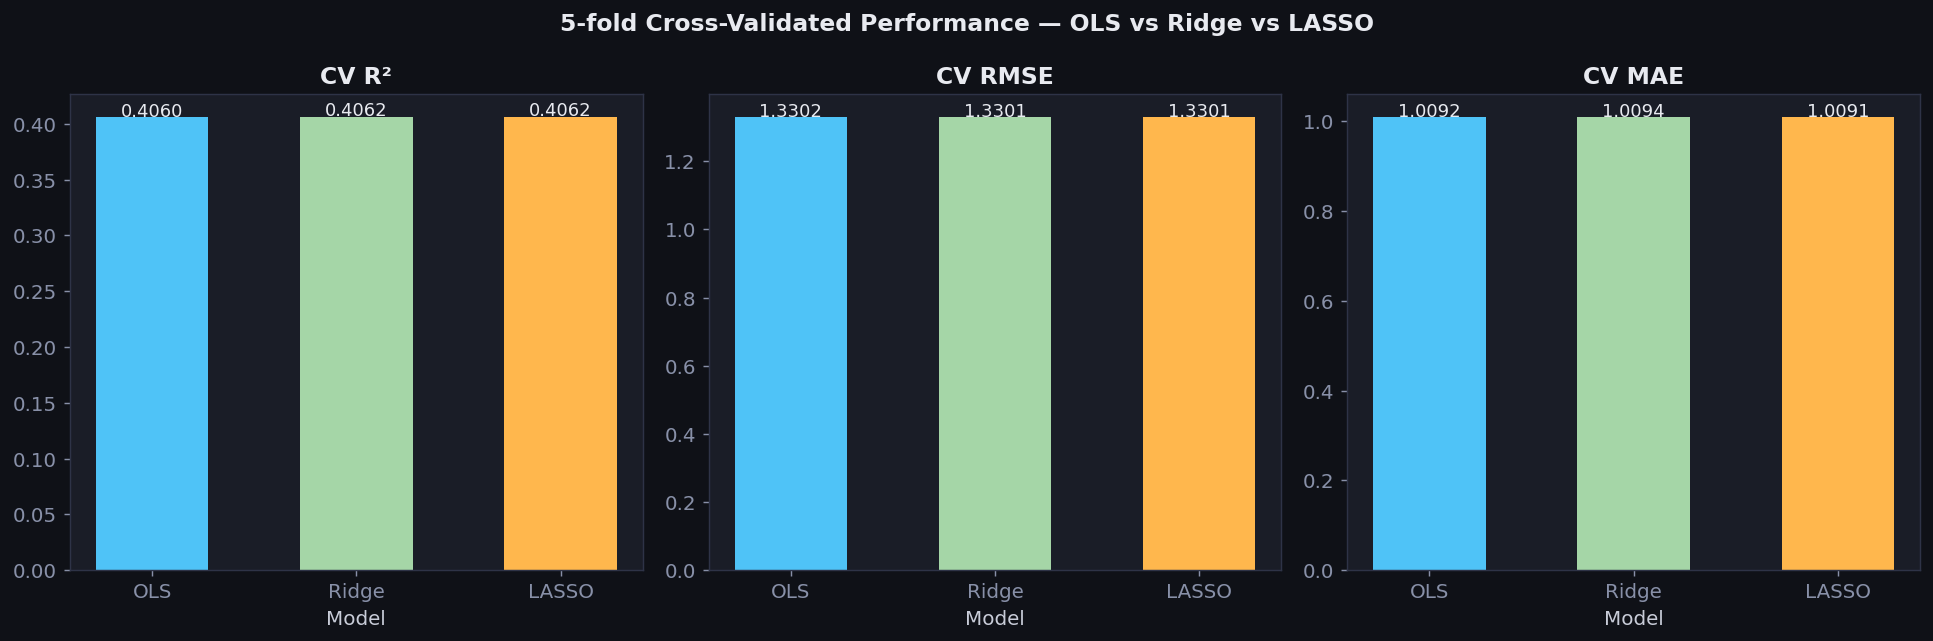

Model  CV R²  CV RMSE  CV MAE  R² std
  OLS 0.4060   1.3302  1.0092  0.0222
Ridge 0.4062   1.3301  1.0094  0.0203
LASSO 0.4062   1.3301  1.0091  0.0209


In [6]:
from sklearn.model_selection import KFold

def cv_report(model, X, y, cv=5, label=''):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    r2s, rmses, maes = [], [], []
    for tr, va in kf.split(X):
        model.fit(X[tr], y[tr])
        p = model.predict(X[va])
        r2s.append(r2_score(y[va], p))
        rmses.append(np.sqrt(mean_squared_error(y[va], p)))
        maes.append(mean_absolute_error(y[va], p))
    return {
        'Model': label,
        'CV R²': round(np.mean(r2s), 4),
        'CV RMSE': round(np.mean(rmses), 4),
        'CV MAE': round(np.mean(maes), 4),
        'R² std': round(np.std(r2s), 4),
    }

results = [
    cv_report(LinearRegression(),                            X_s, y, label='OLS'),
    cv_report(Ridge(alpha=best_ridge_alpha),                 X_s, y, label='Ridge'),
    cv_report(Lasso(alpha=best_lasso_alpha, max_iter=10000), X_s, y, label='LASSO'),
]
perf_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['CV R²', 'CV RMSE', 'CV MAE']
bar_colors = [ACCENT, ACCENT3, ACCENT4]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(perf_df['Model'], perf_df[metric],
                  color=bar_colors, edgecolor='none', width=0.55)
    for bar, val in zip(bars, perf_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', fontsize=10, color='#e8eaf0')
    ax.set_title(metric)
    ax.set_xlabel('Model')

fig.suptitle('5-fold Cross-Validated Performance — OLS vs Ridge vs LASSO',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(perf_df.to_string(index=False))

## 4.6 Shrinkage visualisation — how much do coefficients change?

A direct comparison of how regularisation pulls coefficients toward zero.

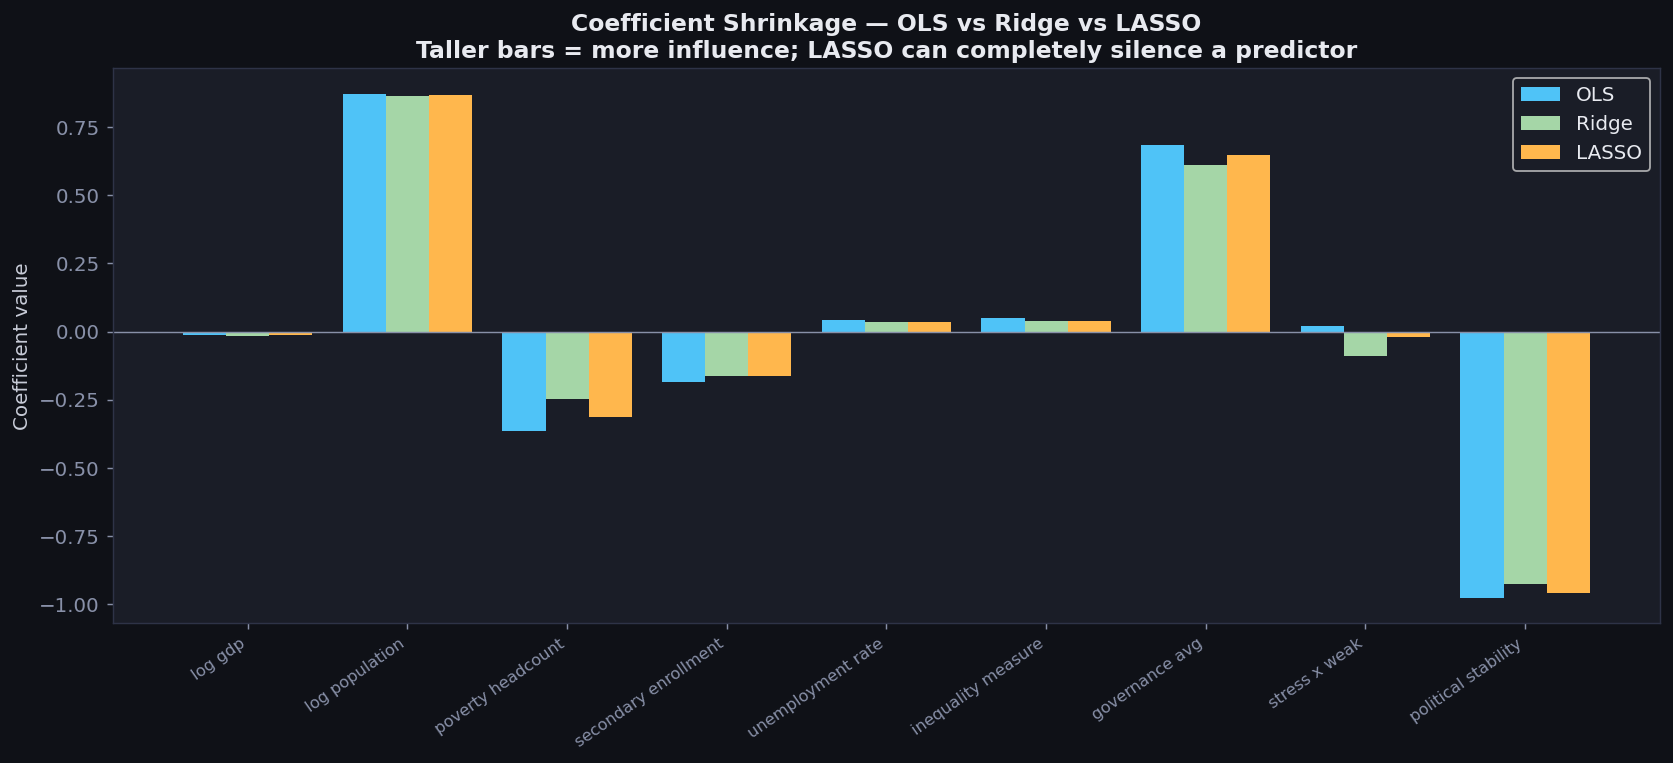

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

x_pos = np.arange(len(FEATURES))
width = 0.27

ax.bar(x_pos - width, ols_coef,   width=width, label='OLS',   color=ACCENT,  edgecolor='none')
ax.bar(x_pos,         ridge_coef, width=width, label='Ridge', color=ACCENT3, edgecolor='none')
ax.bar(x_pos + width, lasso_coef, width=width, label='LASSO', color=ACCENT4, edgecolor='none')

ax.axhline(0, color='#8890a8', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f.replace('_',' ') for f in FEATURES], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Coefficient value')
ax.set_title('Coefficient Shrinkage — OLS vs Ridge vs LASSO\n'
             'Taller bars = more influence; LASSO can completely silence a predictor')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Save performance results for final comparison in Step 6
perf_df['Stage'] = 'regularised_regression'
perf_df.to_csv('regularised.csv', index=False)
print('Regularised regression complete.')
print('Ready for Step 5 ✓')

Regularised regression complete.
Ready for Step 5 ✓
